# Aşama 2: PyTorch ile Zaman Serisi Satış Tahmini (LSTM vs GRU)

Bu projede Rossmann Mağaza Satışları veri setini kullanarak gelecekteki mağaza satışlarını (regresyon) tahmin ediyoruz.
Tüm mağazalar için geçmiş satışlar üzerinden bir `kayan pencere (sliding window)` oluşturulmuş ve modeller eğitilmiştir.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import time

# PyTorch için device ayarı (Eğer CUDA varsa GPU, yoksa CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')

Matplotlib is building the font cache; this may take a moment.


Kullanılan cihaz: cpu


## 1. Veri Yükleme ve Ön İşleme
Sadece açık olan günleri alıyoruz (Open = 1) ve veri setini kronolojik olarak mağazalara göre sıralıyoruz.

In [2]:
# Veriyi yükleme
df = pd.read_csv('train.csv', low_memory=False)

# Sadece açık olan mağazaları filtreleme
df = df[df['Open'] == 1]

# Tarihi datetime objesine çevirme ve sıralama
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Store', 'Date'])

print(f'Toplam kayıt sayısı: {len(df)}')
print(f'Benzersiz mağaza sayısı: {df["Store"].nunique()}')

Toplam kayıt sayısı: 844392
Benzersiz mağaza sayısı: 1115


## 2. Kayan Pencere (Sliding Window) ve Veri Ölçekleme
Zaman serisi ağları (LSTM/GRU) 0 ile 1 arasındaki değerlerle daha iyi çalışır. Tüm satışları ölçeklendiriyoruz.
Ayrıca `seq_length = 7` gün geçmişe bakarak sonraki günü (1. gün) tahmin edeceğiz.

In [3]:
scaler = MinMaxScaler()
df['Sales_Scaled'] = scaler.fit_transform(df[['Sales']])

# Kayan pencere oluşturan fonksiyon. Her mağaza için ayrı ayrı kaydırılır ki farklı mağazaların verileri birbirine karışmasın.
def create_sequences(data_grouped, seq_length):
    xs, ys = [], []
    for store_id, group in data_grouped:
        store_sales = group['Sales_Scaled'].values
        if len(store_sales) <= seq_length:
            continue
        for i in range(len(store_sales) - seq_length):
            xs.append(store_sales[i:(i + seq_length)])
            ys.append(store_sales[i + seq_length])
    return np.array(xs), np.array(ys)

# Zaman serisinde rastgele split yapılmaz. Tarihe göre eğitim ve test olarak ayıralım.
split_date = '2015-06-01'
train_df = df[df['Date'] < split_date]
test_df = df[df['Date'] >= split_date]

seq_length = 7

X_train, y_train = create_sequences(train_df.groupby('Store'), seq_length)
X_test, y_test = create_sequences(test_df.groupby('Store'), seq_length)

# Derin öğrenme için feature boyutunu ekleyelim: (Örnek Sayısı, Zaman Adımı, Feature Sayısı)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print('Eğitim seti boyutları:', X_train.shape, y_train.shape)
print('Test seti boyutları:', X_test.shape, y_test.shape)

Eğitim seti boyutları: (777976, 7, 1) (777976,)
Test seti boyutları: (50806, 7, 1) (50806,)


## 3. PyTorch Dataloader
Tensörlere çevirip eğitim için batch'lere ayırıyoruz.

In [4]:
batch_size = 512

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

## 4. LSTM ve GRU Modellerinin Tanımlanması

In [5]:
class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(SalesLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Sadece son zaman adımını alıyoruz
        return out

class SalesGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(SalesGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

## 5. Eğitim Döngüsü (Training Loop)
Modelleri eğitecek genel bir fonksiyon tanımlıyoruz.

In [6]:
def train_model(model, train_loader, epochs=3, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.6f}')
        
    end_time = time.time()
    training_time = end_time - start_time
    print(f'Eğitim Süresi: {training_time:.2f} saniye')
    return model, training_time

### 5.1 LSTM Eğitim

In [7]:
print("--- LSTM MODEL EĞİTİMİ ---")
lstm_model = SalesLSTM()
lstm_model, lstm_time = train_model(lstm_model, train_loader, epochs=3)

--- LSTM MODEL EĞİTİMİ ---
Epoch [1/3], Loss: 0.002151
Epoch [2/3], Loss: 0.002012
Epoch [3/3], Loss: 0.001945
Eğitim Süresi: 57816.49 saniye


### 5.2 GRU Eğitim

In [8]:
print("\n--- GRU MODEL EĞİTİMİ ---")
gru_model = SalesGRU()
gru_model, gru_time = train_model(gru_model, train_loader, epochs=3)


--- GRU MODEL EĞİTİMİ ---
Epoch [1/3], Loss: 0.002534
Epoch [2/3], Loss: 0.002018
Epoch [3/3], Loss: 0.001942
Eğitim Süresi: 2041.72 saniye


## 6. Değerlendirme ve MSE/RMSE Karşılaştırması
Test seti üzerinde tahmin yapıp, gerçek satış miktarına dönüştürerek metrikleri hesaplıyoruz.

In [9]:
def evaluate_model(model, test_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
    
    # Ölçeklendirmeyi geri al (Inverse Transform)
    predictions = scaler.inverse_transform(predictions)
    return predictions

# Tahminler
lstm_preds = evaluate_model(lstm_model, test_loader)
gru_preds = evaluate_model(gru_model, test_loader)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metriklerin Hesaplanması
lstm_mse = mean_squared_error(y_true, lstm_preds)
lstm_rmse = np.sqrt(lstm_mse)

gru_mse = mean_squared_error(y_true, gru_preds)
gru_rmse = np.sqrt(gru_mse)

print(f'LSTM - MSE: {lstm_mse:.2f}, RMSE: {lstm_rmse:.2f} (Eğitim Süresi: {lstm_time:.2f} sn)')
print(f'GRU  - MSE: {gru_mse:.2f}, RMSE: {gru_rmse:.2f} (Eğitim Süresi: {gru_time:.2f} sn)')

LSTM - MSE: 3070191.99, RMSE: 1752.20 (Eğitim Süresi: 57816.49 sn)
GRU  - MSE: 3095708.35, RMSE: 1759.46 (Eğitim Süresi: 2041.72 sn)


## 7. Sonuçların Görselleştirilmesi
Rastgele seçilen tek bir mağazanın (Örn: İlk mağaza) test dönemindeki gerçek vs tahmin edilen satışlarını karşılaştıralım.

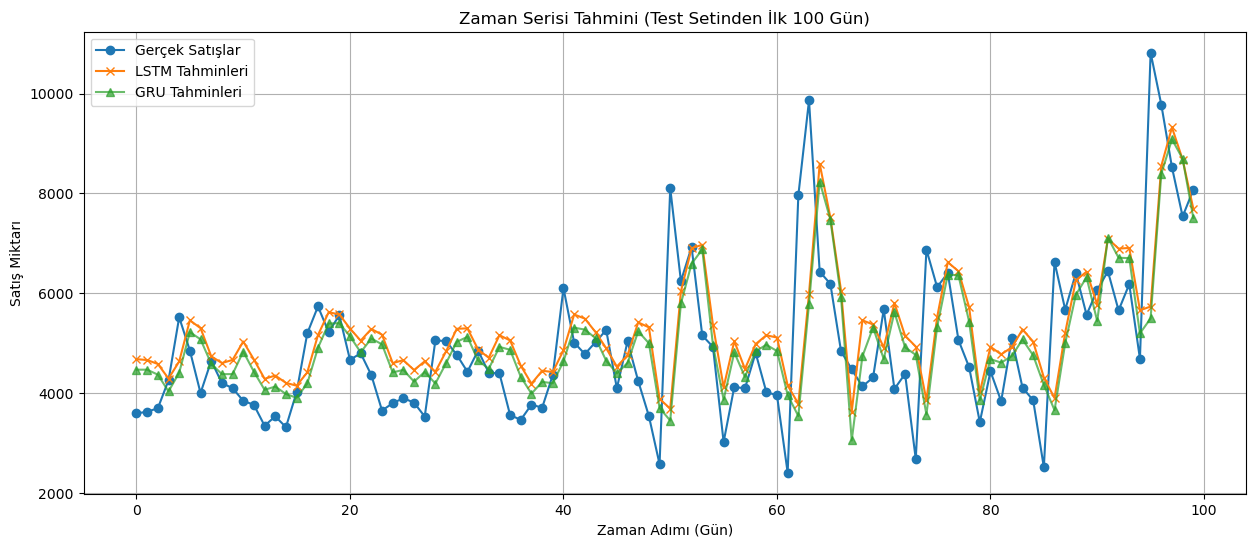

In [10]:
# Sadece belirli bir kesiti grafiğe dökelim (Görselin anlaşılır olması için)
plt.figure(figsize=(15, 6))
plt.plot(y_true[:100], label='Gerçek Satışlar', marker='o')
plt.plot(lstm_preds[:100], label='LSTM Tahminleri', marker='x')
plt.plot(gru_preds[:100], label='GRU Tahminleri', marker='^', alpha=0.7)
plt.title('Zaman Serisi Tahmini (Test Setinden İlk 100 Gün)')
plt.xlabel('Zaman Adımı (Gün)')
plt.ylabel('Satış Miktarı')
plt.legend()
plt.grid(True)
plt.show()